# Multiclass _ DCNN

TensorFlow version: 2.20.0
GPU available: False
Total image files found: 1091
Valid images after cleaning: 1091
Removed corrupt/unreadable images: 0

Class distribution:
class_name
Non_Tumor           535
Viable_Tumor        291
Non_Viable_Tumor    265
Name: count, dtype: int64

Split sizes:
Train: 872
Val  : 109
Test : 110
Found 872 validated image filenames belonging to 3 classes.
Found 109 validated image filenames belonging to 3 classes.
Found 110 validated image filenames belonging to 3 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 120, 120, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,091,459 (19.42 MB)

 Trainable params: 5,091,459 (19.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.4141 - loss: 1.7647
Epoch 1: val_accuracy improved from None to 0.48624, saving model to best_osteosarcoma_dcnn.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 266ms/step - accuracy: 0.4587 - loss: 1.3011 - val_accuracy: 0.4862 - val_loss: 0.9455 - learning_rate: 0.0010
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.5545 - loss: 0.8648
Epoch 2: val_accuracy improved from 0.48624 to 0.52294, saving model to best_osteosarcoma_dcnn.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 236ms/step - accuracy: 0.5734 - loss: 0.8438 - val_accuracy: 0.5229 - val_loss: 0.8984 - learning_rate: 0.0010
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.6041 - loss: 0.7781
Epoch 3: val_accuracy improved from 0.52294 to 0.68807, saving model to best_osteosarcoma_dcnn.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.6273 - loss: 0.7437 - val_accuracy: 0.6881 - val_loss: 0.7863 - learning_rate: 0.0010
Epoch 4/100
28/2

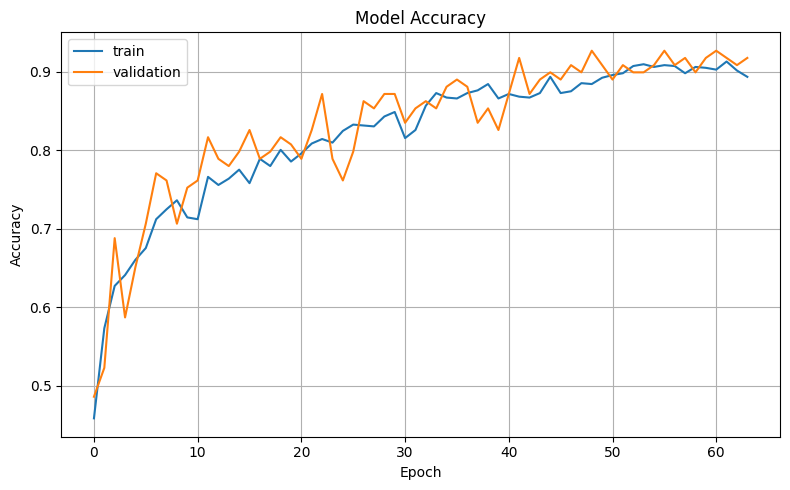

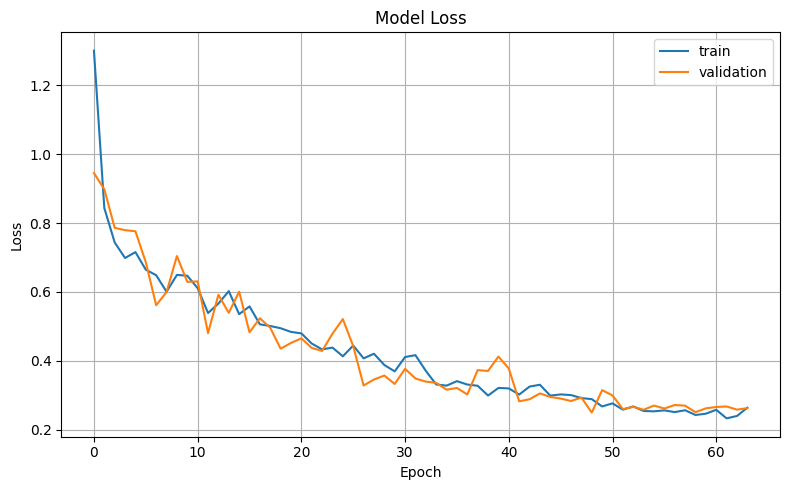

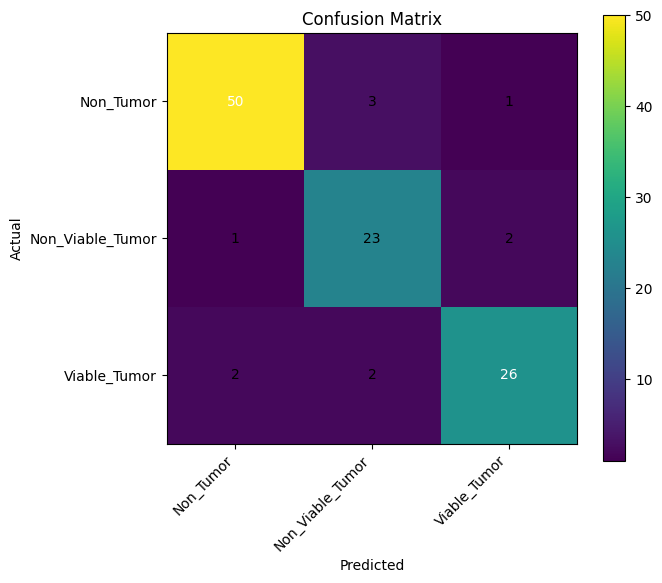


Saved model: osteosarcoma_dcnn_final.keras


In [1]:
# ============================================================
# Osteosarcoma 3-class classification - faithful reimplementation
# Based on the paper's described DCNN architecture
# Folder structure:
# E:\Purdue Spring 2026\Spring 2026 BIOL 59500\data
#   ├── Non_Tumor
#   ├── Non_Viable_Tumor
#   └── Viable_Tumor
# ============================================================

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings("ignore")

# =========================
# 1. SETTINGS
# =========================
DATA_DIR = r"E:\Purdue Spring 2026\Spring 2026 BIOL 59500\data"

IMG_HEIGHT = 120
IMG_WIDTH = 120
CHANNELS = 3
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001
SEED = 42

CLASS_NAMES = ["Non_Tumor", "Non_Viable_Tumor", "Viable_Tumor"]
CLASS_TO_INDEX = {
    "Non_Tumor": 0,
    "Non_Viable_Tumor": 1,
    "Viable_Tumor": 2
}
NUM_CLASSES = len(CLASS_NAMES)

# Split similar to paper's later section: 80/10/10
TRAIN_SIZE = 0.80
VAL_SIZE = 0.10
TEST_SIZE = 0.10

# =========================
# 2. REPRODUCIBILITY
# =========================
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# 3. CHECK GPU
# =========================
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpus) > 0)
if gpus:
    print("GPU:", gpus[0].name)

# =========================
# 4. LOAD FILE PATHS
# =========================
data_path = Path(DATA_DIR)
if not data_path.exists():
    raise FileNotFoundError(f"Dataset path not found: {DATA_DIR}")

all_files = []
all_labels = []

valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

for class_name in CLASS_NAMES:
    class_dir = data_path / class_name
    if not class_dir.exists():
        raise FileNotFoundError(f"Missing class folder: {class_dir}")

    for file_path in class_dir.rglob("*"):
        if file_path.suffix.lower() in valid_ext:
            all_files.append(str(file_path))
            all_labels.append(CLASS_TO_INDEX[class_name])

if len(all_files) == 0:
    raise ValueError("No image files found in dataset folders.")

print(f"Total image files found: {len(all_files)}")

# =========================
# 5. REMOVE CORRUPT IMAGES
# =========================
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False

clean_files = []
clean_labels = []

for f, y in zip(all_files, all_labels):
    if is_valid_image(f):
        clean_files.append(f)
        clean_labels.append(y)

print(f"Valid images after cleaning: {len(clean_files)}")
print(f"Removed corrupt/unreadable images: {len(all_files) - len(clean_files)}")

if len(clean_files) == 0:
    raise ValueError("No valid images remain after cleaning.")

# =========================
# 6. DATAFRAME
# =========================
df = pd.DataFrame({
    "filename": clean_files,
    "label": clean_labels
})
df["class_name"] = df["label"].map({v: k for k, v in CLASS_TO_INDEX.items()})

print("\nClass distribution:")
print(df["class_name"].value_counts())

# =========================
# 7. SPLIT DATA
# =========================
train_df, temp_df = train_test_split(
    df,
    test_size=(1 - TRAIN_SIZE),
    stratify=df["label"],
    random_state=SEED
)

# temp is 20% -> split equally into val/test = 10/10
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

# convert labels to string for flow_from_dataframe + categorical mode
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label_str"] = train_df["class_name"]
val_df["label_str"] = val_df["class_name"]
test_df["label_str"] = test_df["class_name"]

# =========================
# 8. NORMALIZATION FUNCTION
#    Paper mentions Z-score normalization.
#    We implement sample-wise standardization here.
# =========================
def zscore_preprocess(x):
    x = x.astype("float32")
    mean = np.mean(x, axis=(0, 1), keepdims=True)
    std = np.std(x, axis=(0, 1), keepdims=True)
    std = np.where(std < 1e-7, 1.0, std)
    x = (x - mean) / std
    return x

# =========================
# 9. DATA GENERATORS
# =========================
train_datagen = ImageDataGenerator(
    preprocessing_function=zscore_preprocess,
    rotation_range=360,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    channel_shift_range=10.0,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=zscore_preprocess
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="label_str",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filename",
    y_col="label_str",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="label_str",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

# =========================
# 10. BUILD MODEL
#     Figure suggests:
#     Conv64 -> Pool
#     Conv128 -> Pool
#     Conv256 -> Pool
#     Conv512 -> Pool
#     Conv512 -> Pool
#     Flatten -> Dropout(0.25) -> Dense -> Output
#
#     Dense hidden size is not clearly written in paper,
#     so 256 is used as a practical faithful choice.
# =========================
def build_dcnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), num_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(512, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(512, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dropout(0.25),

        layers.Dense(256, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

model = build_dcnn()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =========================
# 11. CALLBACKS
# =========================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_osteosarcoma_dcnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# =========================
# 12. TRAIN
# =========================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# =========================
# 13. LOAD BEST MODEL
# =========================
best_model = tf.keras.models.load_model("best_osteosarcoma_dcnn.keras")

# =========================
# 14. EVALUATE
# =========================
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f}%")

# =========================
# 15. PREDICTIONS
# =========================
pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
target_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# =========================
# 16. PLOT ACCURACY / LOSS
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 17. PLOT CONFUSION MATRIX
# =========================
plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45, ha="right")
plt.yticks(tick_marks, target_names)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# =========================
# 18. SAVE FINAL MODEL
# =========================
best_model.save("osteosarcoma_dcnn_final.keras")
print("\nSaved model: osteosarcoma_dcnn_final.keras")

# Binary_DCNN (Non_Viable_Tumor, Viable_Tumor)

TensorFlow version: 2.20.0
GPU available: False
Total image files found: 556
Valid images after cleaning: 556
Removed corrupt/unreadable images: 0

Class distribution:
class_name
Viable_Tumor        291
Non_Viable_Tumor    265
Name: count, dtype: int64

Split sizes:
Train: 444
Val  : 56
Test : 56
Found 444 validated image filenames belonging to 2 classes.
Found 56 validated image filenames belonging to 2 classes.
Found 56 validated image filenames belonging to 2 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 120, 120, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 15, 15, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,090,945 (19.42 MB)

 Trainable params: 5,090,945 (19.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.5059 - loss: 0.9134
Epoch 1: val_accuracy improved from None to 0.53571, saving model to best_osteosarcoma_binary_dcnn.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 278ms/step - accuracy: 0.5315 - loss: 0.7882 - val_accuracy: 0.5357 - val_loss: 0.6745 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.4823 - loss: 0.6672
Epoch 2: val_accuracy improved from 0.53571 to 0.76786, saving model to best_osteosarcoma_binary_dcnn.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 263ms/step - accuracy: 0.5856 - loss: 0.6264 - val_accuracy: 0.7679 - val_loss: 0.4905 - learning_rate: 0.0010
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.6699 - loss: 0.5911
Epoch 3: val_accuracy did not improve from 0.76786
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 243ms/step - accuracy: 0.6847 - loss: 0.5992 - val_accuracy: 0.7143 - val_loss: 0.6058 - learning_rate: 0.0010
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - a

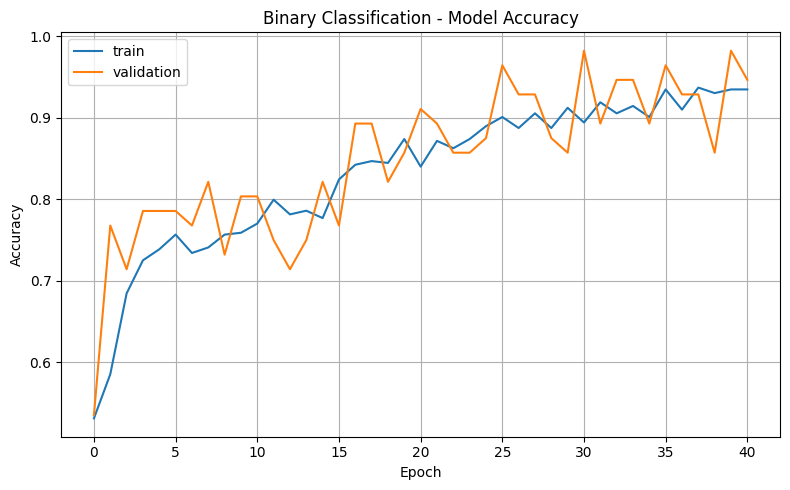

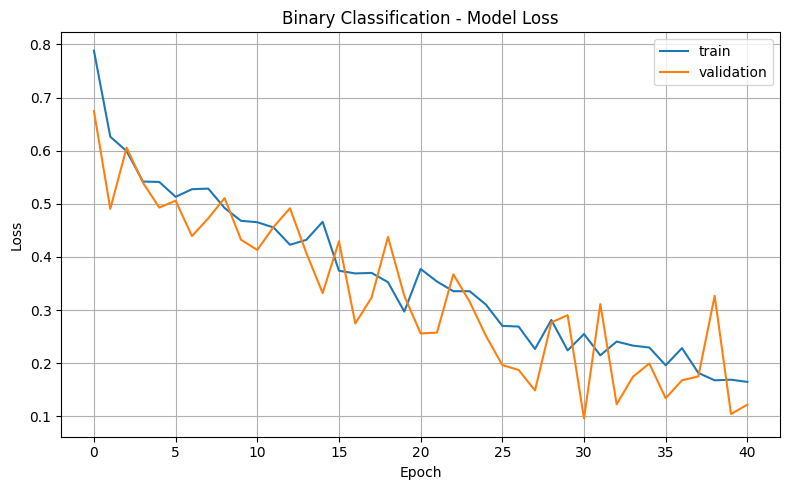

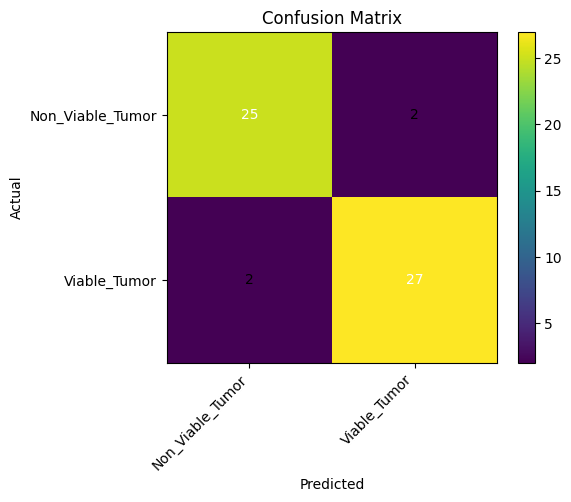

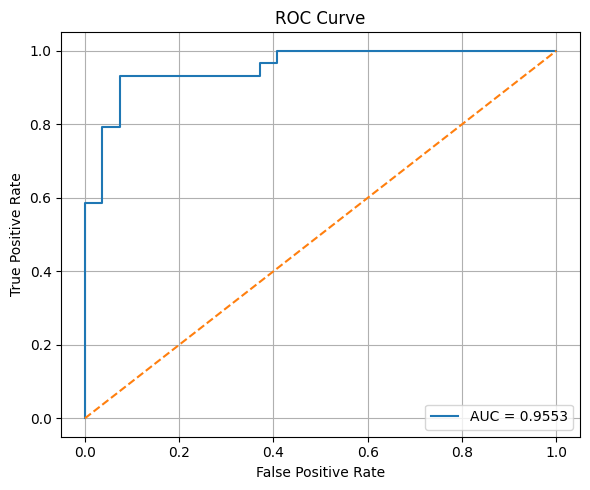


Saved model: osteosarcoma_binary_dcnn_final.keras


In [2]:
# ============================================================
# Osteosarcoma Binary Classification (DCNN)
# Classes used:
#   - Non_Viable_Tumor -> 0
#   - Viable_Tumor     -> 1
#
# Dataset path:
# E:\Purdue Spring 2026\Spring 2026 BIOL 59500\data
#   ├── Non_Tumor
#   ├── Non_Viable_Tumor
#   └── Viable_Tumor
#
# This code ignores Non_Tumor for binary classification.
# ============================================================

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings("ignore")

# =========================
# 1. SETTINGS
# =========================
DATA_DIR = r"E:\Purdue Spring 2026\Spring 2026 BIOL 59500\data"

IMG_HEIGHT = 120
IMG_WIDTH = 120
CHANNELS = 3
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
SEED = 42

CLASS_NAMES = ["Non_Viable_Tumor", "Viable_Tumor"]
CLASS_TO_INDEX = {
    "Non_Viable_Tumor": 0,
    "Viable_Tumor": 1
}

# =========================
# 2. REPRODUCIBILITY
# =========================
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# 3. CHECK GPU
# =========================
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpus) > 0)
if gpus:
    print("GPU:", gpus[0].name)

# =========================
# 4. LOAD IMAGE PATHS
# =========================
data_path = Path(DATA_DIR)
if not data_path.exists():
    raise FileNotFoundError(f"Dataset path not found: {DATA_DIR}")

valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

all_files = []
all_labels = []

for class_name in CLASS_NAMES:
    class_dir = data_path / class_name
    if not class_dir.exists():
        raise FileNotFoundError(f"Missing class folder: {class_dir}")

    for file_path in class_dir.rglob("*"):
        if file_path.suffix.lower() in valid_ext:
            all_files.append(str(file_path))
            all_labels.append(CLASS_TO_INDEX[class_name])

if len(all_files) == 0:
    raise ValueError("No image files found in binary class folders.")

print(f"Total image files found: {len(all_files)}")

# =========================
# 5. REMOVE CORRUPT IMAGES
# =========================
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False

clean_files = []
clean_labels = []

for f, y in zip(all_files, all_labels):
    if is_valid_image(f):
        clean_files.append(f)
        clean_labels.append(y)

print(f"Valid images after cleaning: {len(clean_files)}")
print(f"Removed corrupt/unreadable images: {len(all_files) - len(clean_files)}")

if len(clean_files) == 0:
    raise ValueError("No valid images remain after cleaning.")

# =========================
# 6. DATAFRAME
# =========================
df = pd.DataFrame({
    "filename": clean_files,
    "label": clean_labels
})
df["class_name"] = df["label"].map({0: "Non_Viable_Tumor", 1: "Viable_Tumor"})

print("\nClass distribution:")
print(df["class_name"].value_counts())

# =========================
# 7. TRAIN / VAL / TEST SPLIT
#    80 / 10 / 10
# =========================
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

# labels as strings for dataframe generators
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label_str"] = train_df["label"].astype(str)
val_df["label_str"] = val_df["label"].astype(str)
test_df["label_str"] = test_df["label"].astype(str)

# =========================
# 8. Z-SCORE PREPROCESS
# =========================
def zscore_preprocess(x):
    x = x.astype("float32")
    mean = np.mean(x, axis=(0, 1), keepdims=True)
    std = np.std(x, axis=(0, 1), keepdims=True)
    std = np.where(std < 1e-7, 1.0, std)
    x = (x - mean) / std
    return x

# =========================
# 9. DATA GENERATORS
# =========================
train_datagen = ImageDataGenerator(
    preprocessing_function=zscore_preprocess,
    rotation_range=360,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    channel_shift_range=10.0,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=zscore_preprocess
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="label_str",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filename",
    y_col="label_str",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="label_str",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

# =========================
# 10. BUILD PAPER-STYLE DCNN
# =========================
def build_binary_dcnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(512, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(512, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dropout(0.25),
        layers.Dense(256, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

model = build_binary_dcnn()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =========================
# 11. CALLBACKS
# =========================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_osteosarcoma_binary_dcnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

# =========================
# 12. TRAIN
# =========================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# =========================
# 13. LOAD BEST MODEL
# =========================
best_model = tf.keras.models.load_model("best_osteosarcoma_binary_dcnn.keras")

# =========================
# 14. EVALUATE
# =========================
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f}%")

# =========================
# 15. PREDICTIONS
# =========================
pred_probs = best_model.predict(test_generator, verbose=1).ravel()
y_pred = (pred_probs >= 0.5).astype(int)
y_true = test_generator.classes

target_names = ["Non_Viable_Tumor", "Viable_Tumor"]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# =========================
# 16. PLOTS: ACCURACY AND LOSS
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Binary Classification - Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Binary Classification - Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 17. CONFUSION MATRIX PLOT
# =========================
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45, ha="right")
plt.yticks(tick_marks, target_names)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# =========================
# 18. ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(y_true, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 19. SAVE FINAL MODEL
# =========================
best_model.save("osteosarcoma_binary_dcnn_final.keras")
print("\nSaved model: osteosarcoma_binary_dcnn_final.keras")

# Binary Classification: Tumor vs Non-Tumor

TensorFlow version: 2.20.0
GPU available: False
Total images found: 1091
Valid images after cleaning: 1091
Removed corrupt/unreadable images: 0

Original folder distribution:
source_class
Non_Tumor           535
Viable_Tumor        291
Non_Viable_Tumor    265
Name: count, dtype: int64

Binary class distribution:
binary_class_name
Tumor        556
Non_Tumor    535
Name: count, dtype: int64

Split sizes:
Train: 872
Val  : 109
Test : 110
Found 872 validated image filenames belonging to 2 classes.
Found 109 validated image filenames belonging to 2 classes.
Found 110 validated image filenames belonging to 2 classes.

Generator class mapping: {'0': 0, '1': 1}


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 120, 120, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 15, 15, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,090,945 (19.42 MB)

 Trainable params: 5,090,945 (19.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.5515 - loss: 0.8392
Epoch 1: val_accuracy improved from None to 0.85321, saving model to best_tumor_vs_nontumor_dcnn.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 276ms/step - accuracy: 0.6250 - loss: 0.6884 - val_accuracy: 0.8532 - val_loss: 0.4694 - learning_rate: 0.0010
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.7594 - loss: 0.5156
Epoch 2: val_accuracy did not improve from 0.85321
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 251ms/step - accuracy: 0.7741 - loss: 0.5136 - val_accuracy: 0.8349 - val_loss: 0.4216 - learning_rate: 0.0010
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8139 - loss: 0.4409
Epoch 3: val_accuracy did not improve from 0.85321
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - accuracy: 0.8062 - loss: 0.4391 - val_accuracy: 0.8440 - val_loss: 0.3500 - learning_rate: 0.0010
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.8710 - loss: 0.3539
Epoch 4: val_accuracy improv

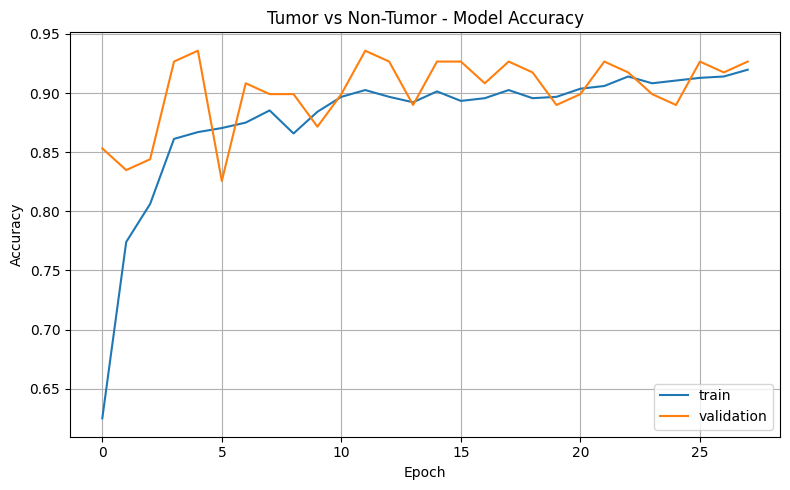

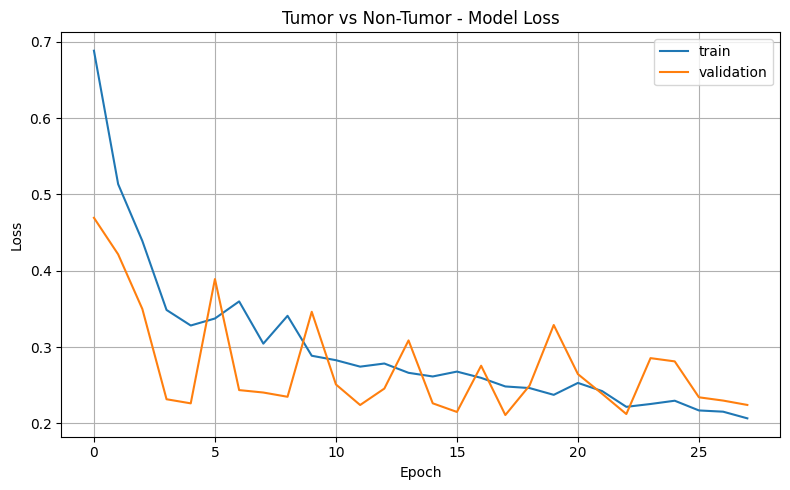

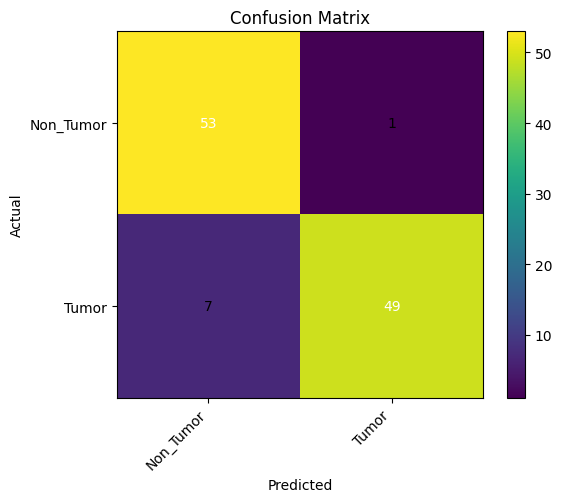

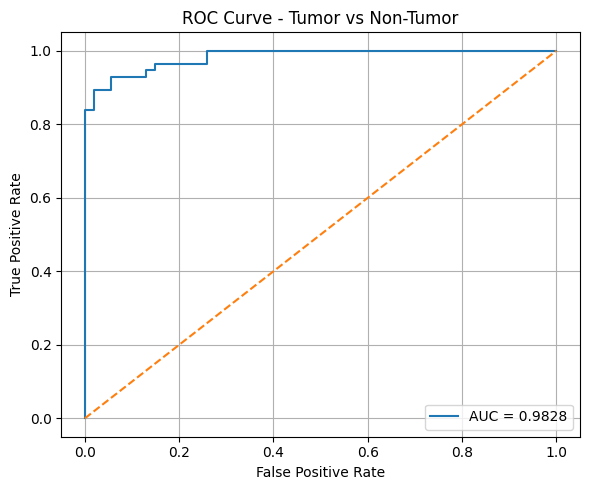


Saved model: tumor_vs_nontumor_dcnn_final.keras


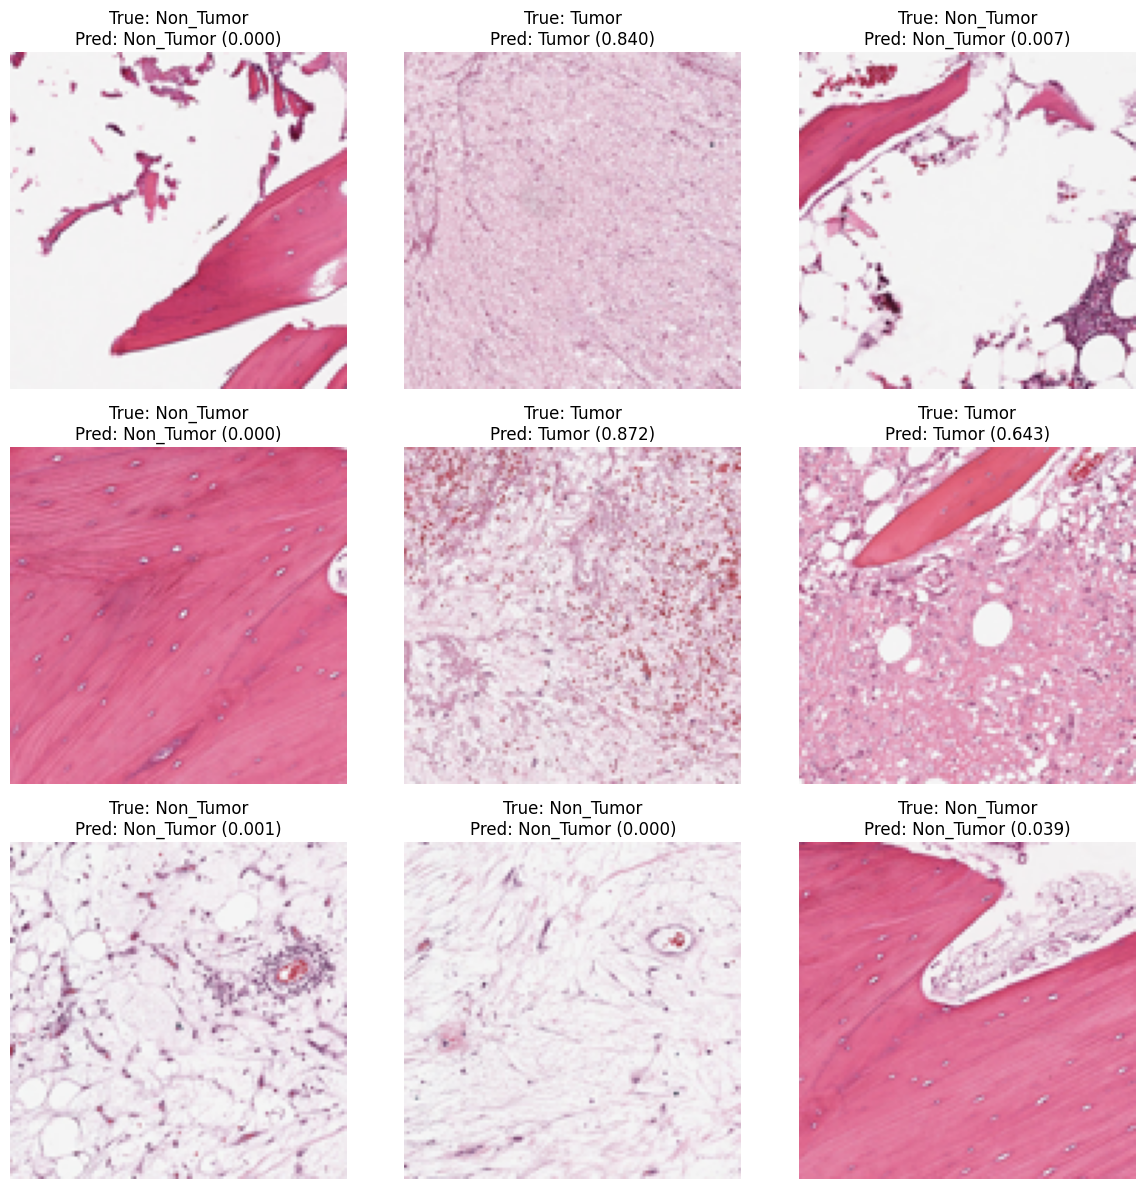

In [3]:
# ============================================================
# Osteosarcoma Binary Classification: Tumor vs Non-Tumor
# Using the paper-style proposed DCNN model
#
# Dataset path:
# E:\Purdue Spring 2026\Spring 2026 BIOL 59500\data
#   ├── Non_Tumor
#   ├── Non_Viable_Tumor
#   └── Viable_Tumor
#
# Label mapping:
#   Non_Tumor                    -> 0
#   Viable_Tumor                -> 1
#   Non_Viable_Tumor            -> 1
# ============================================================

import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings("ignore")

# =========================
# 1. SETTINGS
# =========================
DATA_DIR = r"E:\Purdue Spring 2026\Spring 2026 BIOL 59500\data"

IMG_HEIGHT = 120
IMG_WIDTH = 120
CHANNELS = 3
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
SEED = 42

# Folder names expected in your dataset
SOURCE_FOLDERS = ["Non_Tumor", "Non_Viable_Tumor", "Viable_Tumor"]

# Binary mapping
# Non_Tumor = 0
# Any tumor = 1
FOLDER_TO_BINARY_LABEL = {
    "Non_Tumor": 0,
    "Non_Viable_Tumor": 1,
    "Viable_Tumor": 1
}

BINARY_LABEL_TO_NAME = {
    0: "Non_Tumor",
    1: "Tumor"
}

# =========================
# 2. REPRODUCIBILITY
# =========================
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# 3. CHECK GPU
# =========================
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpus) > 0)
if gpus:
    print("GPU:", gpus[0].name)

# =========================
# 4. LOAD FILES
# =========================
data_path = Path(DATA_DIR)
if not data_path.exists():
    raise FileNotFoundError(f"Dataset path not found: {DATA_DIR}")

valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

all_files = []
all_labels = []
all_source_classes = []

for folder_name in SOURCE_FOLDERS:
    folder_path = data_path / folder_name
    if not folder_path.exists():
        raise FileNotFoundError(f"Missing folder: {folder_path}")

    for file_path in folder_path.rglob("*"):
        if file_path.suffix.lower() in valid_ext:
            all_files.append(str(file_path))
            all_labels.append(FOLDER_TO_BINARY_LABEL[folder_name])
            all_source_classes.append(folder_name)

if len(all_files) == 0:
    raise ValueError("No image files found.")

print(f"Total images found: {len(all_files)}")

# =========================
# 5. REMOVE CORRUPT IMAGES
# =========================
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False

clean_files = []
clean_labels = []
clean_source_classes = []

for f, y, c in zip(all_files, all_labels, all_source_classes):
    if is_valid_image(f):
        clean_files.append(f)
        clean_labels.append(y)
        clean_source_classes.append(c)

print(f"Valid images after cleaning: {len(clean_files)}")
print(f"Removed corrupt/unreadable images: {len(all_files) - len(clean_files)}")

if len(clean_files) == 0:
    raise ValueError("No valid images remain after cleaning.")

# =========================
# 6. DATAFRAME
# =========================
df = pd.DataFrame({
    "filename": clean_files,
    "label": clean_labels,
    "source_class": clean_source_classes
})
df["binary_class_name"] = df["label"].map(BINARY_LABEL_TO_NAME)

print("\nOriginal folder distribution:")
print(df["source_class"].value_counts())

print("\nBinary class distribution:")
print(df["binary_class_name"].value_counts())

# =========================
# 7. SPLIT DATA: 80 / 10 / 10
# =========================
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label_str"] = train_df["label"].astype(str)
val_df["label_str"] = val_df["label"].astype(str)
test_df["label_str"] = test_df["label"].astype(str)

# =========================
# 8. PREPROCESSING
# Paper mentions Z-score normalization.
# We apply per-image Z-score normalization.
# =========================
def zscore_preprocess(x):
    x = x.astype("float32")
    mean = np.mean(x, axis=(0, 1), keepdims=True)
    std = np.std(x, axis=(0, 1), keepdims=True)
    std = np.where(std < 1e-7, 1.0, std)
    x = (x - mean) / std
    return x

# =========================
# 9. DATA GENERATORS
# Based on augmentation parameters reported in the paper
# =========================
train_datagen = ImageDataGenerator(
    preprocessing_function=zscore_preprocess,
    rotation_range=360,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    channel_shift_range=10.0,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=zscore_preprocess
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="label_str",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filename",
    y_col="label_str",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="label_str",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nGenerator class mapping:", train_generator.class_indices)

# =========================
# 10. BUILD OUR DCNN MODEL
# Paper-style architecture:
# 64 -> 128 -> 256 -> 512 -> 512 conv layers
# each with max pooling
# then dropout and dense output
# =========================
def build_tumor_vs_nontumor_dcnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(512, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(512, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dropout(0.25),
        layers.Dense(256, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

model = build_tumor_vs_nontumor_dcnn()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =========================
# 11. CALLBACKS
# =========================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_tumor_vs_nontumor_dcnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

# =========================
# 12. TRAIN
# =========================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# =========================
# 13. LOAD BEST MODEL
# =========================
best_model = tf.keras.models.load_model("best_tumor_vs_nontumor_dcnn.keras")

# =========================
# 14. EVALUATE
# =========================
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f}%")

# =========================
# 15. PREDICT
# =========================
pred_probs = best_model.predict(test_generator, verbose=1).ravel()
y_pred = (pred_probs >= 0.5).astype(int)
y_true = test_generator.classes

target_names = ["Non_Tumor", "Tumor"]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# =========================
# 16. PLOT ACCURACY
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Tumor vs Non-Tumor - Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 17. PLOT LOSS
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Tumor vs Non-Tumor - Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 18. CONFUSION MATRIX PLOT
# =========================
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45, ha="right")
plt.yticks(tick_marks, target_names)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# =========================
# 19. ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(y_true, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Tumor vs Non-Tumor")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 20. SAVE FINAL MODEL
# =========================
best_model.save("tumor_vs_nontumor_dcnn_final.keras")
print("\nSaved model: tumor_vs_nontumor_dcnn_final.keras")

# =========================
# 21. OPTIONAL: SHOW A FEW PREDICTIONS
# =========================
sample_df = test_df.sample(min(9, len(test_df)), random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(12, 12))
for i in range(len(sample_df)):
    img = Image.open(sample_df.loc[i, "filename"]).convert("RGB").resize((IMG_WIDTH, IMG_HEIGHT))
    img_arr = np.array(img).astype("float32")
    img_proc = zscore_preprocess(img_arr)
    pred = best_model.predict(np.expand_dims(img_proc, axis=0), verbose=0)[0][0]
    pred_label = "Tumor" if pred >= 0.5 else "Non_Tumor"
    true_label = BINARY_LABEL_TO_NAME[sample_df.loc[i, "label"]]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label} ({pred:.3f})")
    plt.axis("off")

plt.tight_layout()
plt.show()

# DCNN Done

# Start with comparison

In [6]:
# ============================================================
# FULL COMPARISON FRAMEWORK FOR 3 TASKS
# Proposed DCNN vs transfer learning models
# ============================================================

import os
import time
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ============================================================
# 1. USER SETTINGS
# ============================================================
DATA_DIR = r"E:\Purdue Spring 2026\Spring 2026 BIOL 59500\data"
OUTPUT_DIR = r"E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs"

IMG_SIZE = (120, 120)    # paper-style size
CHANNELS = 3
BATCH_SIZE = 16          # safer for GPU memory
SEED = 42
LEARNING_RATE = 1e-3
USE_IMAGENET_WEIGHTS = True   # set False if offline
RUN_OPTIONAL_NEWER_MODELS = True

# epochs by task
TASK_EPOCHS = {
    "task_3class": 100,
    "task_viable_vs_nonviable": 50,
    "task_tumor_vs_nontumor": 50
}

# early stopping
EARLY_STOPPING_PATIENCE = 10
REDUCE_LR_PATIENCE = 4

# requested models
BASE_MODELS_TO_RUN = [
    "DCNN",
    "VGG16",
    "ResNet152V2",
    "EfficientNetB7",
    "DenseNet201",
    "MobileNet",
    "Xception"
]

# optional newer models
OPTIONAL_MODELS = [
    "InceptionV3",
    "InceptionResNetV2",
    "EfficientNetV2B0",
    "ConvNeXtTiny"
]

# ============================================================
# 2. REPRODUCIBILITY
# ============================================================
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# 3. CREATE OUTPUT FOLDERS
# ============================================================
output_root = Path(OUTPUT_DIR)
output_root.mkdir(parents=True, exist_ok=True)

# ============================================================
# 4. CHECK ENVIRONMENT
# ============================================================
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpus) > 0)
if gpus:
    print("GPU:", gpus[0].name)

data_path = Path(DATA_DIR)
if not data_path.exists():
    raise FileNotFoundError(f"Dataset path not found: {DATA_DIR}")

# ============================================================
# 5. TASK DEFINITIONS
# ============================================================
TASKS = {
    "task_3class": {
        "description": "Non_Tumor vs Non_Viable_Tumor vs Viable_Tumor",
        "folders": ["Non_Tumor", "Non_Viable_Tumor", "Viable_Tumor"],
        "folder_to_label": {
            "Non_Tumor": 0,
            "Non_Viable_Tumor": 1,
            "Viable_Tumor": 2
        },
        "label_to_name": {
            0: "Non_Tumor",
            1: "Non_Viable_Tumor",
            2: "Viable_Tumor"
        },
        "mode": "multiclass"
    },
    "task_viable_vs_nonviable": {
        "description": "Non_Viable_Tumor vs Viable_Tumor",
        "folders": ["Non_Viable_Tumor", "Viable_Tumor"],
        "folder_to_label": {
            "Non_Viable_Tumor": 0,
            "Viable_Tumor": 1
        },
        "label_to_name": {
            0: "Non_Viable_Tumor",
            1: "Viable_Tumor"
        },
        "mode": "binary"
    },
    "task_tumor_vs_nontumor": {
        "description": "Non_Tumor vs Tumor",
        "folders": ["Non_Tumor", "Non_Viable_Tumor", "Viable_Tumor"],
        "folder_to_label": {
            "Non_Tumor": 0,
            "Non_Viable_Tumor": 1,
            "Viable_Tumor": 1
        },
        "label_to_name": {
            0: "Non_Tumor",
            1: "Tumor"
        },
        "mode": "binary"
    }
}

# ============================================================
# 6. IMAGE VALIDATION
# ============================================================
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False

# ============================================================
# 7. PREPROCESSING FUNCTIONS
# ============================================================
def zscore_preprocess(x):
    x = x.astype("float32")
    mean = np.mean(x, axis=(0, 1), keepdims=True)
    std = np.std(x, axis=(0, 1), keepdims=True)
    std = np.where(std < 1e-7, 1.0, std)
    x = (x - mean) / std
    return x

def identity_preprocess(x):
    return x

def get_preprocess_function(model_name):
    if model_name == "DCNN":
        return zscore_preprocess

    apps = tf.keras.applications

    preprocess_map = {
        "VGG16": apps.vgg16.preprocess_input,
        "ResNet152V2": apps.resnet_v2.preprocess_input,
        "EfficientNetB7": apps.efficientnet.preprocess_input,
        "DenseNet201": apps.densenet.preprocess_input,
        "MobileNet": apps.mobilenet.preprocess_input,
        "Xception": apps.xception.preprocess_input,
    }

    if hasattr(apps, "inception_v3"):
        preprocess_map["InceptionV3"] = apps.inception_v3.preprocess_input
    if hasattr(apps, "inception_resnet_v2"):
        preprocess_map["InceptionResNetV2"] = apps.inception_resnet_v2.preprocess_input
    if hasattr(apps, "efficientnet_v2"):
        preprocess_map["EfficientNetV2B0"] = apps.efficientnet_v2.preprocess_input
    if hasattr(apps, "convnext"):
        preprocess_map["ConvNeXtTiny"] = apps.convnext.preprocess_input

    return preprocess_map.get(model_name, identity_preprocess)

# ============================================================
# 8. DATA COLLECTION FOR EACH TASK
# ============================================================
def build_task_dataframe(task_cfg):
    files = []
    labels = []
    source_classes = []

    for folder_name in task_cfg["folders"]:
        folder_path = data_path / folder_name
        if not folder_path.exists():
            raise FileNotFoundError(f"Missing folder: {folder_path}")

        for file_path in folder_path.rglob("*"):
            if file_path.suffix.lower() in VALID_EXT:
                files.append(str(file_path))
                labels.append(task_cfg["folder_to_label"][folder_name])
                source_classes.append(folder_name)

    if len(files) == 0:
        raise ValueError("No image files found.")

    clean_files = []
    clean_labels = []
    clean_sources = []

    for f, y, s in zip(files, labels, source_classes):
        if is_valid_image(f):
            clean_files.append(f)
            clean_labels.append(y)
            clean_sources.append(s)

    if len(clean_files) == 0:
        raise ValueError("No valid images remain after cleaning.")

    df = pd.DataFrame({
        "filename": clean_files,
        "label": clean_labels,
        "source_class": clean_sources
    })
    df["class_name"] = df["label"].map(task_cfg["label_to_name"])
    return df

# ============================================================
# 9. TRAIN / VAL / TEST SPLIT
# ============================================================
def stratified_split(df, seed=42):
    train_df, temp_df = train_test_split(
        df,
        test_size=0.20,
        stratify=df["label"],
        random_state=seed
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df["label"],
        random_state=seed
    )
    return train_df.copy(), val_df.copy(), test_df.copy()

# ============================================================
# 10. CLASS WEIGHTS
# ============================================================
def get_class_weights(train_labels):
    classes = np.unique(train_labels)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=train_labels
    )
    return {int(c): float(w) for c, w in zip(classes, weights)}

# ============================================================
# 11. DATA GENERATORS
# ============================================================
def make_generators(train_df, val_df, test_df, task_cfg, model_name):
    preprocess_fn = get_preprocess_function(model_name)
    mode = task_cfg["mode"]
    ordered_class_names = [task_cfg["label_to_name"][i] for i in sorted(task_cfg["label_to_name"].keys())]

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=360,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        channel_shift_range=10.0,
        horizontal_flip=True,
        fill_mode="nearest"
    )

    test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )

    if mode == "binary":
        train_df["target"] = train_df["label"].astype(str)
        val_df["target"] = val_df["label"].astype(str)
        test_df["target"] = test_df["label"].astype(str)

        train_gen = train_datagen.flow_from_dataframe(
            dataframe=train_df,
            x_col="filename",
            y_col="target",
            target_size=IMG_SIZE,
            color_mode="rgb",
            class_mode="binary",
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED
        )
        val_gen = test_datagen.flow_from_dataframe(
            dataframe=val_df,
            x_col="filename",
            y_col="target",
            target_size=IMG_SIZE,
            color_mode="rgb",
            class_mode="binary",
            batch_size=BATCH_SIZE,
            shuffle=False
        )
        test_gen = test_datagen.flow_from_dataframe(
            dataframe=test_df,
            x_col="filename",
            y_col="target",
            target_size=IMG_SIZE,
            color_mode="rgb",
            class_mode="binary",
            batch_size=BATCH_SIZE,
            shuffle=False
        )
    else:
        train_df["target"] = train_df["class_name"]
        val_df["target"] = val_df["class_name"]
        test_df["target"] = test_df["class_name"]

        train_gen = train_datagen.flow_from_dataframe(
            dataframe=train_df,
            x_col="filename",
            y_col="target",
            classes=ordered_class_names,
            target_size=IMG_SIZE,
            color_mode="rgb",
            class_mode="categorical",
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED
        )
        val_gen = test_datagen.flow_from_dataframe(
            dataframe=val_df,
            x_col="filename",
            y_col="target",
            classes=ordered_class_names,
            target_size=IMG_SIZE,
            color_mode="rgb",
            class_mode="categorical",
            batch_size=BATCH_SIZE,
            shuffle=False
        )
        test_gen = test_datagen.flow_from_dataframe(
            dataframe=test_df,
            x_col="filename",
            y_col="target",
            classes=ordered_class_names,
            target_size=IMG_SIZE,
            color_mode="rgb",
            class_mode="categorical",
            batch_size=BATCH_SIZE,
            shuffle=False
        )

    return train_gen, val_gen, test_gen

# ============================================================
# 12. OUR PROPOSED DCNN
# ============================================================
def build_dcnn(num_classes, task_mode):
    if task_mode == "binary":
        output_units = 1
        output_activation = "sigmoid"
        loss = "binary_crossentropy"
    else:
        output_units = num_classes
        output_activation = "softmax"
        loss = "categorical_crossentropy"

    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(512, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(512, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dropout(0.25),
        layers.Dense(256, activation="relu"),
        layers.Dense(output_units, activation=output_activation)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=loss,
        metrics=["accuracy"]
    )
    return model

# ============================================================
# 13. TRANSFER LEARNING MODEL BUILDERS
# ============================================================
def get_imagenet_weights():
    return "imagenet" if USE_IMAGENET_WEIGHTS else None

def build_transfer_model(model_name, num_classes, task_mode):
    apps = tf.keras.applications
    weights_choice = get_imagenet_weights()
    input_shape = (IMG_SIZE[0], IMG_SIZE[1], CHANNELS)

    builders = {
        "VGG16": getattr(apps, "VGG16", None),
        "ResNet152V2": getattr(apps, "ResNet152V2", None),
        "EfficientNetB7": getattr(apps, "EfficientNetB7", None),
        "DenseNet201": getattr(apps, "DenseNet201", None),
        "MobileNet": getattr(apps, "MobileNet", None),
        "Xception": getattr(apps, "Xception", None),
        "InceptionV3": getattr(apps, "InceptionV3", None),
        "InceptionResNetV2": getattr(apps, "InceptionResNetV2", None),
        "EfficientNetV2B0": getattr(apps, "EfficientNetV2B0", None),
        "ConvNeXtTiny": getattr(apps, "ConvNeXtTiny", None),
    }

    builder = builders.get(model_name, None)
    if builder is None:
        raise ValueError(f"Model not available in your TensorFlow build: {model_name}")

    try:
        base_model = builder(
            include_top=False,
            weights=weights_choice,
            input_shape=input_shape
        )
    except Exception as e:
        print(f"[WARNING] {model_name}: could not load ImageNet weights. Falling back to random init.")
        print("Reason:", str(e))
        base_model = builder(
            include_top=False,
            weights=None,
            input_shape=input_shape
        )

    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.25)(x)

    if task_mode == "binary":
        outputs = layers.Dense(1, activation="sigmoid")(x)
        loss = "binary_crossentropy"
    else:
        outputs = layers.Dense(num_classes, activation="softmax")(x)
        loss = "categorical_crossentropy"

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=loss,
        metrics=["accuracy"]
    )

    return model

# ============================================================
# 14. MASTER MODEL BUILDER
# ============================================================
def build_model(model_name, num_classes, task_mode):
    if model_name == "DCNN":
        return build_dcnn(num_classes, task_mode)
    return build_transfer_model(model_name, num_classes, task_mode)

# ============================================================
# 15. PLOTS
# ============================================================
def plot_history(history, save_path_prefix):
    hist = history.history

    if "accuracy" in hist and "val_accuracy" in hist:
        plt.figure(figsize=(7, 5))
        plt.plot(hist["accuracy"], label="train")
        plt.plot(hist["val_accuracy"], label="validation")
        plt.title("Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(str(save_path_prefix) + "_accuracy.png", dpi=300)
        plt.close()

    if "loss" in hist and "val_loss" in hist:
        plt.figure(figsize=(7, 5))
        plt.plot(hist["loss"], label="train")
        plt.plot(hist["val_loss"], label="validation")
        plt.title("Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(str(save_path_prefix) + "_loss.png", dpi=300)
        plt.close()

def plot_confusion_matrix(cm, class_names, save_path, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

def plot_binary_roc(y_true, y_prob, save_path, title="ROC Curve"):
    try:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.title(title)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.close()
        return roc_auc
    except Exception:
        return np.nan

def plot_task_barplot(results_df, metric_col, save_path, title):
    if results_df.empty:
        return

    df_plot = results_df.sort_values(metric_col, ascending=False).copy()
    plt.figure(figsize=(10, 6))
    plt.bar(df_plot["model_name"], df_plot[metric_col])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric_col)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

# ============================================================
# 16. EVALUATION
# ============================================================
def evaluate_model(model, test_gen, task_cfg):
    mode = task_cfg["mode"]
    class_names = [task_cfg["label_to_name"][i] for i in sorted(task_cfg["label_to_name"].keys())]

    y_true = test_gen.classes

    if mode == "binary":
        y_prob = model.predict(test_gen, verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        accuracy = accuracy_score(y_true, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", zero_division=0
        )
        cm = confusion_matrix(y_true, y_pred)

        try:
            roc_auc = roc_auc_score(y_true, y_prob)
        except Exception:
            roc_auc = np.nan

        report_dict = classification_report(
            y_true, y_pred,
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )

        return {
            "accuracy": float(accuracy),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "roc_auc": float(roc_auc) if not np.isnan(roc_auc) else np.nan,
            "confusion_matrix": cm,
            "y_true": y_true,
            "y_pred": y_pred,
            "y_prob": y_prob,
            "report_dict": report_dict
        }

    else:
        y_prob = model.predict(test_gen, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)

        accuracy = accuracy_score(y_true, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )
        cm = confusion_matrix(y_true, y_pred)

        try:
            roc_auc = roc_auc_score(
                tf.keras.utils.to_categorical(y_true, num_classes=len(class_names)),
                y_prob,
                average="macro",
                multi_class="ovr"
            )
        except Exception:
            roc_auc = np.nan

        report_dict = classification_report(
            y_true, y_pred,
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )

        return {
            "accuracy": float(accuracy),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "roc_auc": float(roc_auc) if not np.isnan(roc_auc) else np.nan,
            "confusion_matrix": cm,
            "y_true": y_true,
            "y_pred": y_pred,
            "y_prob": y_prob,
            "report_dict": report_dict
        }

# ============================================================
# 17. AVAILABLE MODELS
# ============================================================
def get_available_models():
    models_to_run = BASE_MODELS_TO_RUN.copy()

    if RUN_OPTIONAL_NEWER_MODELS:
        for m in OPTIONAL_MODELS:
            if hasattr(tf.keras.applications, m):
                models_to_run.append(m)
            else:
                print(f"[INFO] Optional model not available in this TF version: {m}")

    unique_models = []
    for m in models_to_run:
        if m not in unique_models:
            unique_models.append(m)
    return unique_models

AVAILABLE_MODELS = get_available_models()

# ============================================================
# 18. TRAIN ONE MODEL
# ============================================================
def train_one_model(task_name, task_cfg, train_df, val_df, test_df, model_name, task_out_dir):
    print("\n" + "=" * 80)
    print(f"TASK: {task_name}")
    print(f"DESCRIPTION: {task_cfg['description']}")
    print(f"MODEL: {model_name}")
    print("=" * 80)

    tf.keras.backend.clear_session()

    train_gen, val_gen, test_gen = make_generators(
        train_df.copy(), val_df.copy(), test_df.copy(), task_cfg, model_name
    )

    class_weights = get_class_weights(train_df["label"].values)
    num_classes = len(task_cfg["label_to_name"])
    epochs = TASK_EPOCHS[task_name]

    model = build_model(model_name, num_classes, task_cfg["mode"])

    model_dir = task_out_dir / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    best_model_path = model_dir / f"best_{model_name}.keras"

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(best_model_path),
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=REDUCE_LR_PATIENCE,
            min_lr=1e-6,
            verbose=1
        )
    ]

    start_time = time.time()

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    total_seconds = time.time() - start_time
    seconds_per_epoch = total_seconds / max(len(history.history.get("loss", [1])), 1)

    # load best model if saved
    if best_model_path.exists():
        model = tf.keras.models.load_model(str(best_model_path))

    eval_out = evaluate_model(model, test_gen, task_cfg)

    # save plots
    plot_history(history, model_dir / model_name)

    class_names = [task_cfg["label_to_name"][i] for i in sorted(task_cfg["label_to_name"].keys())]
    plot_confusion_matrix(
        eval_out["confusion_matrix"],
        class_names,
        str(model_dir / f"{model_name}_confusion_matrix.png"),
        title=f"{model_name} - {task_name}"
    )

    if task_cfg["mode"] == "binary":
        roc_auc = plot_binary_roc(
            eval_out["y_true"],
            eval_out["y_prob"],
            str(model_dir / f"{model_name}_roc.png"),
            title=f"{model_name} - {task_name}"
        )
        eval_out["roc_auc"] = roc_auc

    # save report json
    with open(model_dir / f"{model_name}_classification_report.json", "w") as f:
        json.dump(eval_out["report_dict"], f, indent=2)

    # save model summary
    with open(model_dir / f"{model_name}_summary.txt", "w", encoding="utf-8") as f:
        model.summary(print_fn=lambda x: f.write(x + "\n"))

    # save final model
    final_model_path = model_dir / f"{model_name}_final.keras"
    model.save(str(final_model_path))

    result_row = {
        "task_name": task_name,
        "task_description": task_cfg["description"],
        "model_name": model_name,
        "mode": task_cfg["mode"],
        "train_samples": len(train_df),
        "val_samples": len(val_df),
        "test_samples": len(test_df),
        "num_classes": num_classes,
        "accuracy": eval_out["accuracy"],
        "precision": eval_out["precision"],
        "recall": eval_out["recall"],
        "f1_score": eval_out["f1_score"],
        "roc_auc": eval_out["roc_auc"],
        "epochs_ran": len(history.history.get("loss", [])),
        "seconds_per_epoch": seconds_per_epoch,
        "total_minutes": total_seconds / 60.0,
        "best_model_path": str(best_model_path),
        "final_model_path": str(final_model_path)
    }

    return result_row

# ============================================================
# 19. MAIN LOOP
# ============================================================
all_results = []

for task_name, task_cfg in TASKS.items():
    print("\n" + "#" * 100)
    print(f"STARTING TASK: {task_name} | {task_cfg['description']}")
    print("#" * 100)

    task_out_dir = output_root / task_name
    task_out_dir.mkdir(parents=True, exist_ok=True)

    df = build_task_dataframe(task_cfg)

    print("\nOriginal folder distribution:")
    print(df["source_class"].value_counts())

    print("\nTask label distribution:")
    print(df["class_name"].value_counts())

    train_df, val_df, test_df = stratified_split(df, seed=SEED)

    print("\nSplit sizes:")
    print("Train:", len(train_df))
    print("Val  :", len(val_df))
    print("Test :", len(test_df))

    train_df.to_csv(task_out_dir / "train_split.csv", index=False)
    val_df.to_csv(task_out_dir / "val_split.csv", index=False)
    test_df.to_csv(task_out_dir / "test_split.csv", index=False)

    task_results = []

    for model_name in AVAILABLE_MODELS:
        try:
            result_row = train_one_model(
                task_name, task_cfg, train_df, val_df, test_df, model_name, task_out_dir
            )
            task_results.append(result_row)
            all_results.append(result_row)

        except tf.errors.ResourceExhaustedError as e:
            print(f"[SKIPPED] {model_name} due to GPU/CPU memory issue.")
            print("Try smaller batch size or fewer models.")
        except Exception as e:
            print(f"[SKIPPED] {model_name} due to error:")
            print(str(e))

    task_results_df = pd.DataFrame(task_results)
    task_results_csv = task_out_dir / f"{task_name}_results.csv"
    task_results_df.to_csv(task_results_csv, index=False)

    if not task_results_df.empty:
        plot_task_barplot(
            task_results_df,
            metric_col="accuracy",
            save_path=str(task_out_dir / f"{task_name}_accuracy_barplot.png"),
            title=f"{task_name} - Accuracy Comparison"
        )
        plot_task_barplot(
            task_results_df,
            metric_col="f1_score",
            save_path=str(task_out_dir / f"{task_name}_f1_barplot.png"),
            title=f"{task_name} - F1 Score Comparison"
        )

        # pretty top results print
        print("\nTop models by accuracy:")
        print(task_results_df.sort_values("accuracy", ascending=False)[
            ["model_name", "accuracy", "precision", "recall", "f1_score", "roc_auc", "total_minutes"]
        ].head(10))

# ============================================================
# 20. SAVE OVERALL RESULTS
# ============================================================
all_results_df = pd.DataFrame(all_results)
overall_csv = output_root / "all_tasks_model_comparison.csv"
all_results_df.to_csv(overall_csv, index=False)

print("\n" + "=" * 100)
print("ALL TASKS FINISHED")
print("Results saved to:", OUTPUT_DIR)
print("=" * 100)

if not all_results_df.empty:
    print("\nOverall summary:")
    print(all_results_df.sort_values(["task_name", "accuracy"], ascending=[True, False])[
        ["task_name", "model_name", "accuracy", "precision", "recall", "f1_score", "roc_auc", "total_minutes"]
    ])

TensorFlow version: 2.20.0
GPU available: False

####################################################################################################
STARTING TASK: task_3class | Non_Tumor vs Non_Viable_Tumor vs Viable_Tumor
####################################################################################################

Original folder distribution:
source_class
Non_Tumor           535
Viable_Tumor        291
Non_Viable_Tumor    265
Name: count, dtype: int64

Task label distribution:
class_name
Non_Tumor           535
Viable_Tumor        291
Non_Viable_Tumor    265
Name: count, dtype: int64

Split sizes:
Train: 872
Val  : 109
Test : 110

TASK: task_3class
DESCRIPTION: Non_Tumor vs Non_Viable_Tumor vs Viable_Tumor
MODEL: DCNN

Found 872 validated image filenames belonging to 3 classes.
Found 109 validated image filenames belonging to 3 classes.
Found 110 validated image filenames belonging to 3 classes.
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.4555 - loss:


TASK: task_3class
DESCRIPTION: Non_Tumor vs Non_Viable_Tumor vs Viable_Tumor
MODEL: VGG16
Found 872 validated image filenames belonging to 3 classes.
Found 109 validated image filenames belonging to 3 classes.
Found 110 validated image filenames belonging to 3 classes.
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.4579 - loss: 5.6791
Epoch 1: val_accuracy improved from None to 0.75229, saving model to E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_3class\VGG16\best_VGG16.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.5608 - loss: 4.1146 - val_accuracy: 0.7523 - val_loss: 1.2152 - learning_rate: 0.0010
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6479 - loss: 2.2029
Epoch 2: val_accuracy did not improve from 0.75229
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - accuracy: 0.6904 - loss: 2.0985 - val_accuracy: 0.6239 - val_loss: 1.5633 - learning_rate: 0.0010
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step 


TASK: task_3class
DESCRIPTION: Non_Tumor vs Non_Viable_Tumor vs Viable_Tumor
MODEL: ResNet152V2
Found 872 validated image filenames belonging to 3 classes.
Found 109 validated image filenames belonging to 3 classes.
Found 110 validated image filenames belonging to 3 classes.
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.5749 - loss: 1.3961
Epoch 1: val_accuracy improved from None to 0.77064, saving model to E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_3class\ResNet152V2\best_ResNet152V2.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 312ms/step - accuracy: 0.6674 - loss: 1.1193 - val_accuracy: 0.7706 - val_loss: 0.6526 - learning_rate: 0.0010
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.7972 - loss: 0.6052
Epoch 2: val_accuracy improved from 0.77064 to 0.84404, saving model to E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_3class\ResNet152V2\best_ResNet152V2.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 277ms/step - 


TASK: task_3class
DESCRIPTION: Non_Tumor vs Non_Viable_Tumor vs Viable_Tumor
MODEL: EfficientNetB7
Found 872 validated image filenames belonging to 3 classes.
Found 109 validated image filenames belonging to 3 classes.
Found 110 validated image filenames belonging to 3 classes.
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.5906 - loss: 0.9413
Epoch 1: val_accuracy improved from None to 0.59633, saving model to E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_3class\EfficientNetB7\best_EfficientNetB7.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 43s 577ms/step - accuracy: 0.6319 - loss: 0.8680 - val_accuracy: 0.5963 - val_loss: 0.9256 - learning_rate: 0.0010
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.7607 - loss: 0.6241
Epoch 2: val_accuracy improved from 0.59633 to 0.66972, saving model to E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_3class\EfficientNetB7\best_EfficientNetB7.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 24


TASK: task_3class
DESCRIPTION: Non_Tumor vs Non_Viable_Tumor vs Viable_Tumor
MODEL: DenseNet201
Found 872 validated image filenames belonging to 3 classes.
Found 109 validated image filenames belonging to 3 classes.
Found 110 validated image filenames belonging to 3 classes.
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.5937 - loss: 1.2748
Epoch 1: val_accuracy improved from None to 0.72477, saving model to E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_3class\DenseNet201\best_DenseNet201.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 25s 340ms/step - accuracy: 0.6800 - loss: 0.9789 - val_accuracy: 0.7248 - val_loss: 0.5501 - learning_rate: 0.0010
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.7885 - loss: 0.7069
Epoch 2: val_accuracy improved from 0.72477 to 0.79817, saving model to E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_3class\DenseNet201\best_DenseNet201

...


TASK: task_tumor_vs_nontumor
DESCRIPTION: Non_Tumor vs Tumor
MODEL: InceptionV3
Found 872 validated image filenames belonging to 2 classes.
Found 109 validated image filenames belonging to 2 classes.
Found 110 validated image filenames belonging to 2 classes.
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.6607 - loss: 0.9309
Epoch 1: val_accuracy improved from None to 0.82569, saving model to E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_tumor_vs_nontumor\InceptionV3\best_InceptionV3.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 181ms/step - accuracy: 0.7087 - loss: 0.7529 - val_accuracy: 0.8257 - val_loss: 0.4314 - learning_rate: 0.0010
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7608 - loss: 0.5825
Epoch 2: val_accuracy did not improve from 0.82569
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.7959 - loss: 0.4943 - val_accuracy: 0.8073 - val_loss: 0.4139 - learning_rate: 0.0010
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1


TASK: task_tumor_vs_nontumor
DESCRIPTION: Non_Tumor vs Tumor
MODEL: InceptionResNetV2
Found 872 validated image filenames belonging to 2 classes.
Found 109 validated image filenames belonging to 2 classes.
Found 110 validated image filenames belonging to 2 classes.
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6578 - loss: 1.0753
Epoch 1: val_accuracy improved from None to 0.74312, saving model to E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_tumor_vs_nontumor\InceptionResNetV2\best_InceptionResNetV2.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 22s 293ms/step - accuracy: 0.7271 - loss: 0.8505 - val_accuracy: 0.7431 - val_loss: 0.4755 - learning_rate: 0.0010
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8072 - loss: 0.4857
Epoch 2: val_accuracy improved from 0.74312 to 0.78899, saving model to E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_tumor_vs_nontumor\InceptionResNetV2\best_InceptionResNetV2.keras
55/55 ━━━━


TASK: task_tumor_vs_nontumor
DESCRIPTION: Non_Tumor vs Tumor
MODEL: EfficientNetV2B0
Found 872 validated image filenames belonging to 2 classes.
Found 109 validated image filenames belonging to 2 classes.
Found 110 validated image filenames belonging to 2 classes.
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.7657 - loss: 0.4975
Epoch 1: val_accuracy improved from None to 0.86239, saving model to E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_tumor_vs_nontumor\EfficientNetV2B0\best_EfficientNetV2B0.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 17s 234ms/step - accuracy: 0.8028 - loss: 0.4383 - val_accuracy: 0.8624 - val_loss: 0.2917 - learning_rate: 0.0010
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8871 - loss: 0.3065
Epoch 2: val_accuracy improved from 0.86239 to 0.91743, saving model to E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_tumor_vs_nontumor\EfficientNetV2B0\best_EfficientNetV2B0.keras
55/55 ━━━━━━━━━


TASK: task_tumor_vs_nontumor
DESCRIPTION: Non_Tumor vs Tumor
MODEL: ConvNeXtTiny
Found 872 validated image filenames belonging to 2 classes.
Found 109 validated image filenames belonging to 2 classes.
Found 110 validated image filenames belonging to 2 classes.
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.7259 - loss: 0.5655
Epoch 1: val_accuracy improved from None to 0.83486, saving model to E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_tumor_vs_nontumor\ConvNeXtTiny\best_ConvNeXtTiny.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 53s 916ms/step - accuracy: 0.7729 - loss: 0.5046 - val_accuracy: 0.8349 - val_loss: 0.3389 - learning_rate: 0.0010
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.8495 - loss: 0.3570
Epoch 2: val_accuracy improved from 0.83486 to 0.88991, saving model to E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_tumor_vs_nontumor\ConvNeXtTiny\best_ConvNeXtTiny.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 48s 874m


Top models by accuracy:
          model_name  accuracy  precision    recall  f1_score   roc_auc  \
4        DenseNet201  0.927273   0.944444  0.910714  0.927273  0.969907   
9   EfficientNetV2B0  0.927273   0.980000  0.875000  0.924528  0.973545   
5          MobileNet  0.918182   0.979592  0.857143  0.914286  0.977513   
0               DCNN  0.909091   0.942308  0.875000  0.907407  0.983796   
3     EfficientNetB7  0.881818   0.905660  0.857143  0.880734  0.931548   
1              VGG16  0.863636   0.847458  0.892857  0.869565  0.926587   
10      ConvNeXtTiny  0.863636   0.886792  0.839286  0.862385  0.933201   
2        ResNet152V2  0.854545   0.900000  0.803571  0.849057  0.946098   
6           Xception  0.854545   0.857143  0.857143  0.857143  0.923280   
7        InceptionV3  0.854545   0.884615  0.821429  0.851852  0.963294   

    total_minutes  
4       22.153428  
9        5.964369  
5        3.938110  
0        4.783518  
3       19.703429  
1        3.725898  
10       

# Build APP

In [3]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# =========================================================
# PAGE CONFIG
# =========================================================
st.set_page_config(
    page_title="Osteosarcoma Detection App",
    page_icon="🩺",
    layout="centered"
)

# =========================================================
# MODEL PATHS
# CHANGE THESE TO YOUR REAL MODEL PATHS
# =========================================================
MODEL_PATHS = {
    "3-Class Classification": r"E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_3class\DCNN\DCNN_final.keras",
    "Tumor vs Non-Tumor": r"E:\Purdue Spring 2026\Spring 2026 BIOL 59500\comparison_outputs\task_tumor_vs_nontumor\DCNN\DCNN_final.keras"
}

# =========================================================
# LABEL MAPS
# =========================================================
LABEL_MAPS = {
    "3-Class Classification": ["Non_Tumor", "Non_Viable_Tumor", "Viable_Tumor"],
    "Tumor vs Non-Tumor": ["Non_Tumor", "Tumor"]
}

IMG_SIZE = (120, 120)

# =========================================================
# PREPROCESSING
# SAME STYLE USED IN YOUR DCNN CODE
# =========================================================
def zscore_preprocess(x):
    x = x.astype("float32")
    mean = np.mean(x, axis=(0, 1), keepdims=True)
    std = np.std(x, axis=(0, 1), keepdims=True)
    std = np.where(std < 1e-7, 1.0, std)
    x = (x - mean) / std
    return x

def prepare_image(uploaded_image):
    image = uploaded_image.convert("RGB")
    image = image.resize(IMG_SIZE)
    img_array = np.array(image).astype("float32")
    img_array = zscore_preprocess(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    return image, img_array

# =========================================================
# LOAD MODEL
# =========================================================
@st.cache_resource
def load_model(model_path):
    model = tf.keras.models.load_model(model_path)
    return model

# =========================================================
# PREDICTION
# =========================================================
def predict_image(model, processed_img, task_name):
    preds = model.predict(processed_img, verbose=0)

    if task_name == "Tumor vs Non-Tumor":
        prob_tumor = float(preds[0][0])
        prob_non_tumor = 1.0 - prob_tumor

        probs = [prob_non_tumor, prob_tumor]
        pred_index = int(np.argmax(probs))
        pred_label = LABEL_MAPS[task_name][pred_index]

    else:
        probs = preds[0].tolist()
        pred_index = int(np.argmax(probs))
        pred_label = LABEL_MAPS[task_name][pred_index]

    return pred_label, probs

# =========================================================
# UI
# =========================================================
st.title("Osteosarcoma Histopathology Classification")
st.write("Upload an image and choose a trained DCNN task.")

task_name = st.selectbox(
    "Choose task",
    ["3-Class Classification", "Tumor vs Non-Tumor"]
)

uploaded_file = st.file_uploader(
    "Upload histopathology image",
    type=["jpg", "jpeg", "png", "bmp", "tif", "tiff", "webp"]
)

if uploaded_file is not None:
    try:
        image = Image.open(uploaded_file)
        display_img, processed_img = prepare_image(image)

        st.subheader("Uploaded Image")
        st.image(display_img, caption="Input Image", use_container_width=True)

        model_path = MODEL_PATHS[task_name]
        model = load_model(model_path)

        if st.button("Predict"):
            pred_label, probs = predict_image(model, processed_img, task_name)

            st.subheader("Prediction Result")
            st.success(f"Predicted Class: {pred_label}")

            st.subheader("Prediction Probabilities")

            class_names = LABEL_MAPS[task_name]
            for class_name, prob in zip(class_names, probs):
                st.write(f"**{class_name}:** {prob:.4f}")
                st.progress(float(prob))

    except Exception as e:
        st.error(f"Error: {str(e)}")

2026-03-30 03:02:53.617 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 03:02:53.617 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 03:02:54.652 
  command:

    streamlit run c:\Users\i_has\.conda\envs\dl_gpu\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-30 03:02:54.652 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 03:02:54.657 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 03:02:54.657 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 03:02:54.657 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored 

In [1]:
import streamlit as st

st.title("Test App")
st.write("Streamlit is working.")

2026-03-30 03:09:42.056 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 03:09:42.201 
  command:

    streamlit run c:\Users\i_has\.conda\envs\dl_gpu\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-30 03:09:42.201 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 03:09:42.201 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 03:09:42.201 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 03:09:42.201 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 03:09:42.201 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
